In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1pkLk2s89-Etn7zIuYV88L_FvDH3sI8qx')
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,0.0,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,0.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00


In [ ]:
df = df[df['room_type'] == 'Entire home/apt']

In [3]:
df['accommodates'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 25079 entries, 0 to 25078
Series name: accommodates
Non-Null Count  Dtype  
--------------  -----  
25079 non-null  float64
dtypes: float64(1)
memory usage: 196.1 KB


In [5]:
df['bathrooms_text'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 25079 entries, 0 to 25078
Series name: bathrooms_text
Non-Null Count  Dtype 
--------------  ----- 
25079 non-null  object
dtypes: object(1)
memory usage: 196.1+ KB


In [6]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('baths', '', regex=False)

In [7]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('bath', '', regex=False)

In [8]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Half-bath', '.5', regex=False)

In [21]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Half-', '.5', regex=False)

In [9]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared bath', '', regex=False)

In [19]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared','', regex=False)

In [10]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('private bath', '', regex=False)

In [11]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared baths', '', regex=False)

In [13]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('private', '', regex=False)

In [23]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Shared half-', '.5', regex=False)

In [25]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Private half-', '.5', regex=False)

In [17]:
df['bathrooms_text'].head()

,bathrooms_text
0,1.5
1,1
2,1
3,1
4,1


In [26]:
df['bathrooms_text'] = df['bathrooms_text'].astype(float)

<ipython-input-27-0a2357813292>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


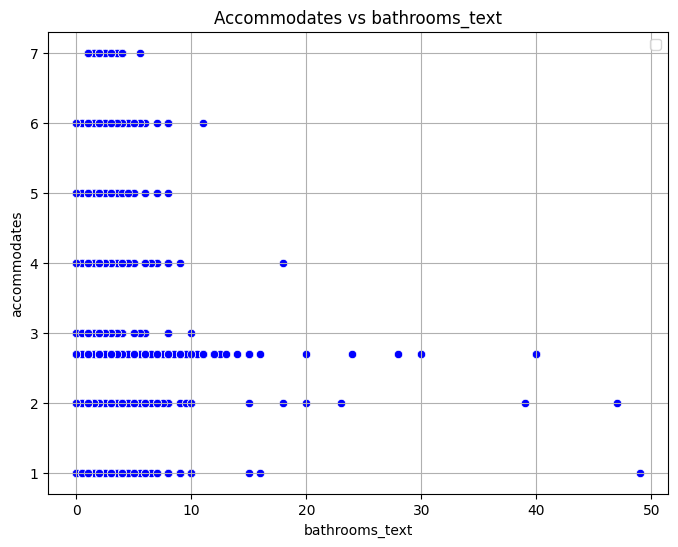

In [27]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='accommodates', x='bathrooms_text',  color = 'blue', data=df)
plt.title('Accommodates vs bathrooms_text')
plt.xlabel('bathrooms_text')
plt.ylabel('accommodates')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
indep= df[['bathrooms_text']]
dep = df[['accommodates']]

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [30]:
model.fit(indep, dep)

LinearRegression()

In [31]:
type(model)

sklearn.linear_model._base.LinearRegression

In [32]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms_text'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[0.18022132]]),
 'rank_': 1,
 'singular_': array([199.25489579]),
 'intercept_': array([2.44040657])}

In [33]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[0.18022132]]
Intercepto: [2.44040657]
y = [0.18022132]x + [2.44040657]


In [34]:
r2 = model.score(indep, dep)
r2

0.03701037476808522

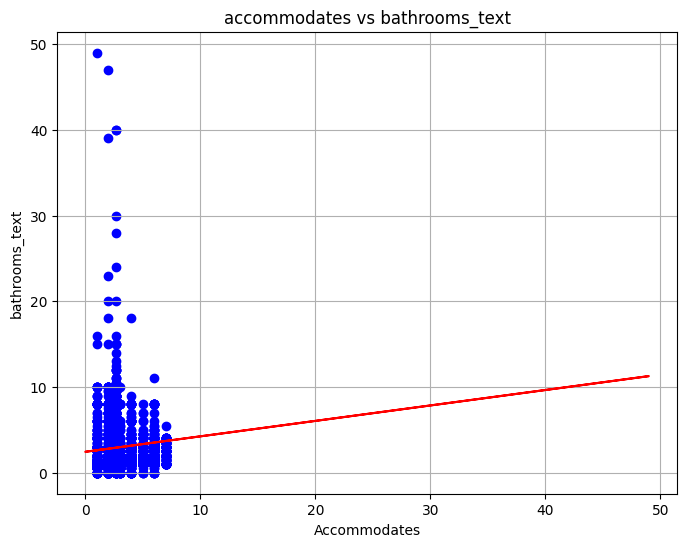

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('accommodates vs bathrooms_text')
plt.xlabel('Accommodates')
plt.ylabel('bathrooms_text')
plt.grid(True)
plt.show()

In [38]:
yPred = model.predict(df[['bathrooms_text']])
yPred

array([[2.71073855],
       [2.62062789],
       [2.62062789],
       ...,
       [2.80084921],
       [2.62062789],
       [2.62062789]])

In [39]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta,Predicciones
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95,2.710739
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70,2.620628
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70,2.620628
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00,2.620628
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00,2.620628


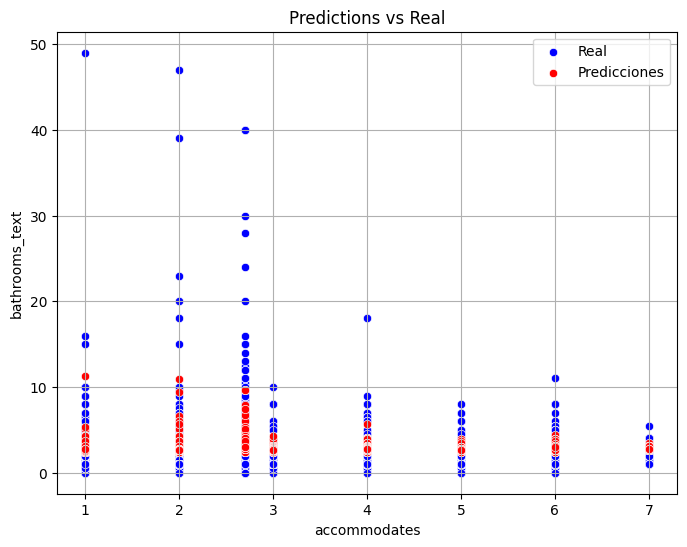

In [41]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='accommodates', y='bathrooms_text', color='blue', data=df, label='Real')
sns.scatterplot(x='accommodates', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
coefDe = model.score(indep, dep)
coefDe

0.03701037476808522

In [43]:
coefCo = np.sqrt(coefDe)
coefCo

0.1923808066520286

In [45]:
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

In [46]:
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-46-1126a6e5cd06>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)


In [47]:
df = df[['host_is_superhost', 'price','accommodates','bathrooms_text']]
df

,host_is_superhost,price,accommodates,bathrooms_text
0,0.0,1793.0,2.0,1.5
1,0.0,2480.0,2.0,1.0
2,0.0,2480.0,2.0,1.0
3,0.0,1286.0,2.0,1.0
4,0.0,1467.0,2.0,1.0
...,...,...,...,...
25074,0.0,1700.0,2.0,1.0
25075,0.0,1700.0,2.0,1.0
25076,0.0,2500.0,4.0,2.0
25077,0.0,1700.0,2.0,1.0


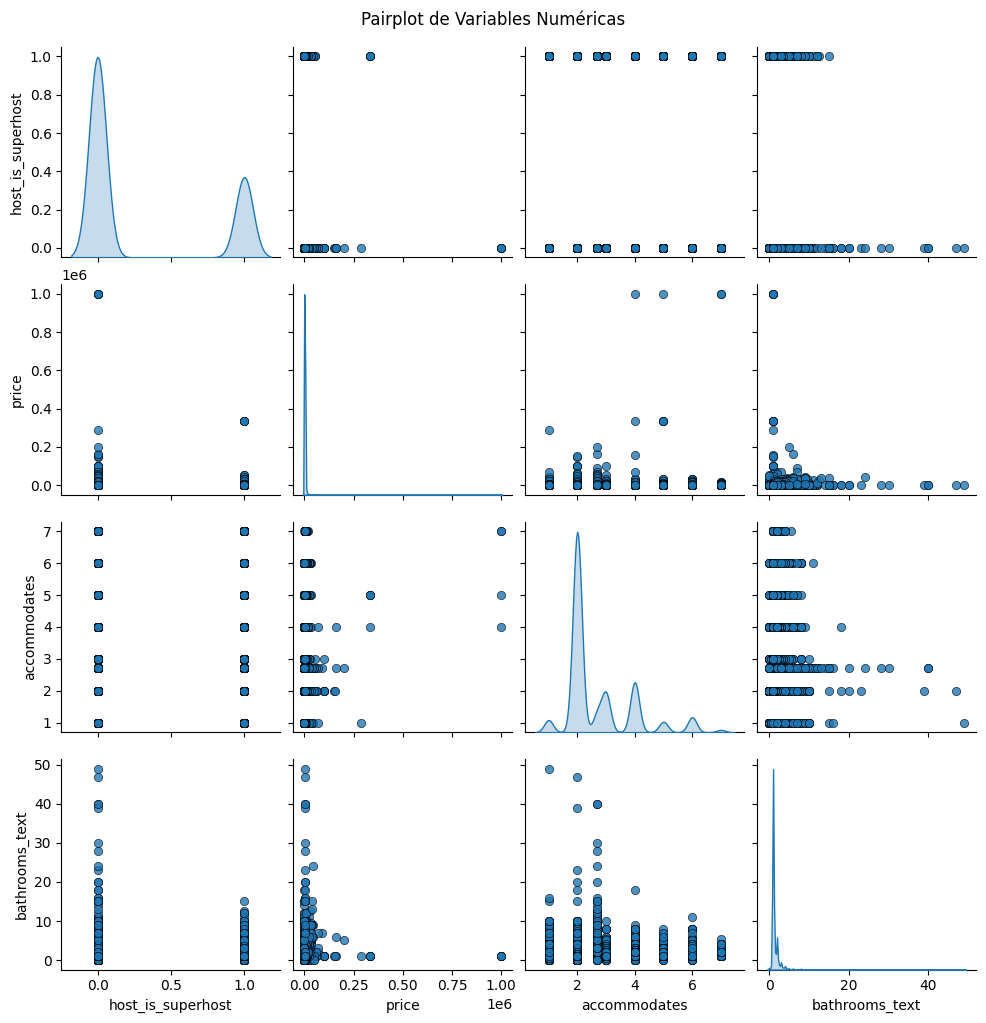

In [48]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.8, 'edgecolor': 'k'})
plt.suptitle('Pairplot de Variables Numéricas', y=1.02)
plt.show()

In [50]:
correlacion = df.corr()
correlacion

,host_is_superhost,price,accommodates,bathrooms_text
host_is_superhost,1.000000,-0.010791,0.060433,-0.009873
price,-0.010791,1.000000,0.067668,0.059513
accommodates,0.060433,0.067668,1.000000,0.192381
bathrooms_text,-0.009873,0.059513,0.192381,1.000000


In [51]:
corr = abs(correlacion)
corr

,host_is_superhost,price,accommodates,bathrooms_text
host_is_superhost,1.000000,0.010791,0.060433,0.009873
price,0.010791,1.000000,0.067668,0.059513
accommodates,0.060433,0.067668,1.000000,0.192381
bathrooms_text,0.009873,0.059513,0.192381,1.000000


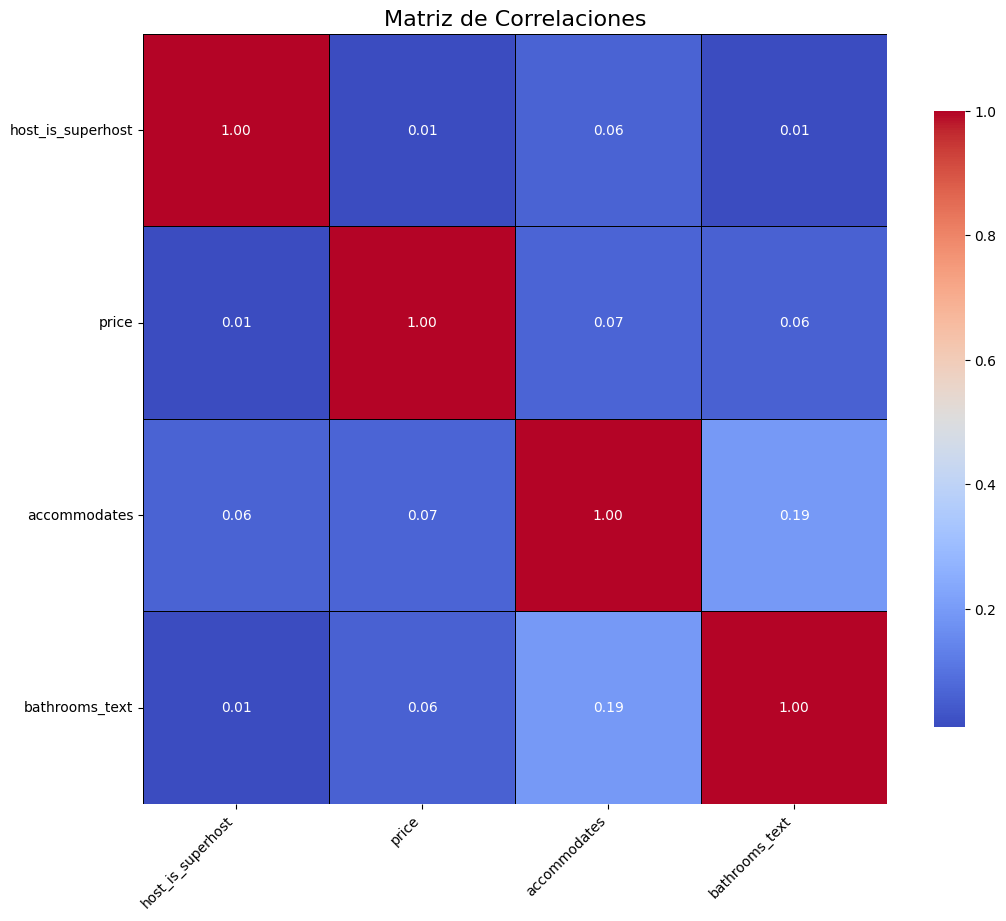

In [52]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black', cbar_kws={'shrink': 0.8}, annot_kws={"size": 10})
plt.title('Matriz de Correlaciones', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()